# Inspecting every candidate WZA fit (SD and mean), on **Kendall's tau**, per block definition × class

**Why this notebook exists.** The mean fit was previously chosen on an unweighted
out-of-sample RMSE. That metric is ~99.6% determined by the small-block bulk — 85% of rolling
points sit below 50 records/block, only 0.37% above 700 — so it could not see that the
empirical mean(Z) falls from ≈0 to **−5.5** (snp clq0.9) and **−7.7** (snp clq0.5) at large
blocks. `const` sits at −0.2 there. That was visible in the figure long before it was visible
in the table.

Re-scoring per block-size stratum did not settle it either: even the top-1% band spans
Xf 380 → 3171 and is dominated by its own lower edge. **The 8–15 blocks past the
rolling-support edge are ~0.02% of rolling points — invisible to any aggregate metric.** For
those blocks the choice must be made on the extrapolated *value*, which is what §3 shows.

Two things to look for:
1. **Does the fit track the decline** at large blocks, or flatten through it?
2. **Does it stay sane past the support edge** (dashed vertical line)? Everything to the
   right of that line is extrapolation.

`_clamp` = fitted inside support, held at the boundary value outside. That clamp is the
entire difference between `deg2_clamp` (−8.5 at the largest snp block) and plain `deg2`
(**−289**).

## ⚠ Everything in this notebook is **Kendall's tau**

One notebook is built per per-record model, because the models differ *qualitatively* here —
so a fit chosen on one does not automatically transfer. The §4 figure in
`cap_poly_decision.ipynb` that prompted this re-examination, with mean(Z) plunging to −5.5,
was **kendall** (that notebook hardcodes `model="kendall"`). LFMM, which corrects for
population structure, is far better behaved. Empirical mean(Z) of the blocks past support:

| class (clq0.9 tile) | kendall | **LFMM** |
|---|---|---|
| snp | **−10.53** | **+3.82** |
| smallindel | −5.78 | −0.30 |
| nonsnp | −5.83 | −0.17 |
| sv | −2.24 | +0.52 |

So the dramatic decline is mostly a kendall phenomenon; on LFMM the mean is near zero in 6 of
8 blockdef × class cases, and *rises* for snp. **Note the opposite sign** — that is why no
hardcoded monotone direction (and no `isotonic(increasing=...)`, and no `increasing="auto"`
inferred from a swamped Spearman rho) can serve all three models, while a clamped polynomial
infers nothing and can.

Companion notebooks: `fit_inspection_kendall.ipynb`, `fit_inspection_lfmm.ipynb`,
`fit_inspection_binomial.ipynb` (quasi-binomial).

In [1]:

import os
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import scipy.stats
from sklearn.isotonic import IsotonicRegression
os.chdir("/global/scratch/projects/fc_moilab/tbellg/kmate")
MA = "analysis/grenenet_gea/phase1_replication/results/multiaxis"
ROLLER, MINE = 50, 40
DEFS = {"clq0.9 tile": "clq09_tile", "clq0.5 tile": "clq05_tile"}
CLASSES = ["snp", "sv", "smallindel", "nonsnp"]

COL = {"const": "#588157", "deg2_clamp": "#B7C0CC", "deg5_clamp": "#3A5A98",
       "deg7_clamp": "#C9A227", "deg10_clamp": "#8a2a1a", "isotonic": "#111111",
       "isotonic_auto": "#111111", "deg15_clamp": "#d62728", "deg20_clamp": "#9467bd",
       "deg2": "#999999", "deg7": "#ff7f0e", "interp": "#e377c2"}

def block_Z(tag, cls, model, axis="bio1"):
    d = pd.read_csv(f"{MA}/wza_in_{tag}/{model}_{cls}_gen9_{axis}.csv",
                    usecols=["block","MAF","pval"])
    d = d[d.pval.notna() & d.block.notna()]
    pV = np.clip(d.pval.rank(method="first").to_numpy()/len(d), 1e-15, 1-1e-3)
    z = scipy.stats.norm.ppf(1-pV); m = d.MAF.to_numpy(float); pq = m*(1-m)
    t = pd.DataFrame({"b": d.block.to_numpy(), "num": pq*z, "den": pq**2})
    g = t.groupby("b").agg(num=("num","sum"), den=("den","sum"), n=("num","size"))
    g = g[g.n>=2]
    return pd.DataFrame({"SNPs": g.n.astype(float), "Z": g.num/np.sqrt(g.den)})

def curve(g):
    s = g.sort_values("SNPs")
    v = s.Z.rolling(ROLLER, min_periods=MINE).var(); m = ~v.isnull()
    return (np.asarray(s.SNPs.rolling(ROLLER,min_periods=MINE).mean()[m], float),
            np.asarray(np.sqrt(v)[m], float),
            np.asarray(s.Z.rolling(ROLLER,min_periods=MINE).mean()[m], float))

def fit(Xs, y, target, kind):
    if kind == "const":         return np.full_like(target, y.mean())
    if kind == "interp":        return np.interp(target, Xs, y)
    if kind == "isotonic":      return IsotonicRegression(increasing=True, out_of_bounds="clip").fit(Xs,y).predict(target)
    if kind == "isotonic_auto": return IsotonicRegression(increasing="auto", out_of_bounds="clip").fit(Xs,y).predict(target)
    deg = int(kind.replace("deg","").replace("_clamp",""))
    mu, sg = Xs.mean(), Xs.std() or 1.0
    p = np.poly1d(np.polyfit((Xs-mu)/sg, y, deg))
    t = np.clip(target, Xs.min(), Xs.max()) if kind.endswith("_clamp") else target
    return p((t-mu)/sg)

MODEL = "kendall"
CACHE = {}
def get(tag, cls, model):
    k = (tag, cls, model)
    if k not in CACHE:
        g = block_Z(tag, cls, model); CACHE[k] = (g,) + curve(g)
    return CACHE[k]
print("ready")


ready


## 1. SD of Z — all viable fits, full range

Black = empirical rolling SD (the thing being predicted). Dashed vertical = the rolling
support edge; everything right of it is extrapolation. A fit that goes ≤ 0 anywhere is
disqualified outright (NaN p, or fabricated `p==0`).

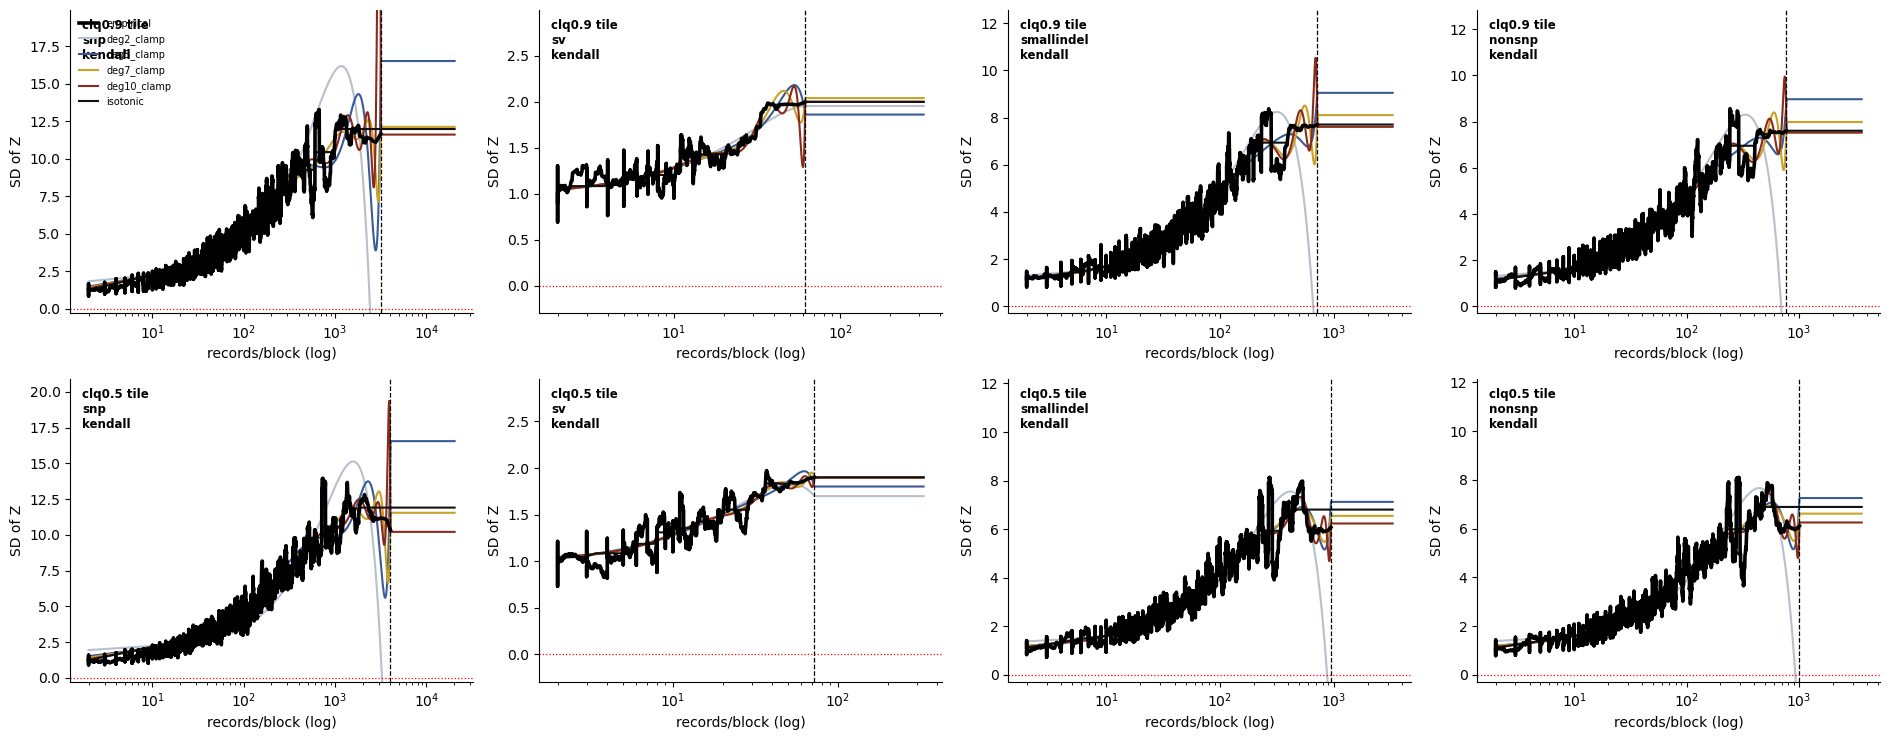

In [2]:

KS = ["deg2_clamp","deg5_clamp","deg7_clamp","deg10_clamp","isotonic"]
for model in [MODEL]:
    fig, axes = plt.subplots(2, 4, figsize=(19, 7.5))
    for i, (lab, tag) in enumerate(DEFS.items()):
        for j, cls in enumerate(CLASSES):
            ax = axes[i][j]; g, X, sd, mn = get(tag, cls, model)
            ax.plot(X, sd, color="k", lw=2.6, zorder=6, label="empirical")
            grid = np.linspace(X.min(), g.SNPs.max(), 700)
            for k in KS:
                ax.plot(grid, fit(X, sd, grid, k), color=COL[k], lw=1.5, label=k)
            ax.axvline(X.max(), ls="--", c="k", lw=.9)
            ax.axhline(0, ls=":", c="r", lw=.9)
            ax.set_xscale("log")
            ax.set_ylim(min(-0.3, sd.min()-0.5), sd.max()*1.5)
            ax.set_xlabel("records/block (log)"); ax.set_ylabel("SD of Z")
            ax.annotate(f"{lab}\n{cls}\n{model}", (0.03,0.97), xycoords="axes fraction",
                        fontsize=8.5, va="top", weight="bold")
            if i==0 and j==0: ax.legend(frameon=False, fontsize=7)
            for sp in ["top","right"]: ax.spines[sp].set_visible(False)
    fig.tight_layout(); plt.show()


## 2. Mean of Z — all viable fits, full range

This is the figure that started the re-examination: the decline at large blocks is obvious,
and `const` (green) flattens straight through it.

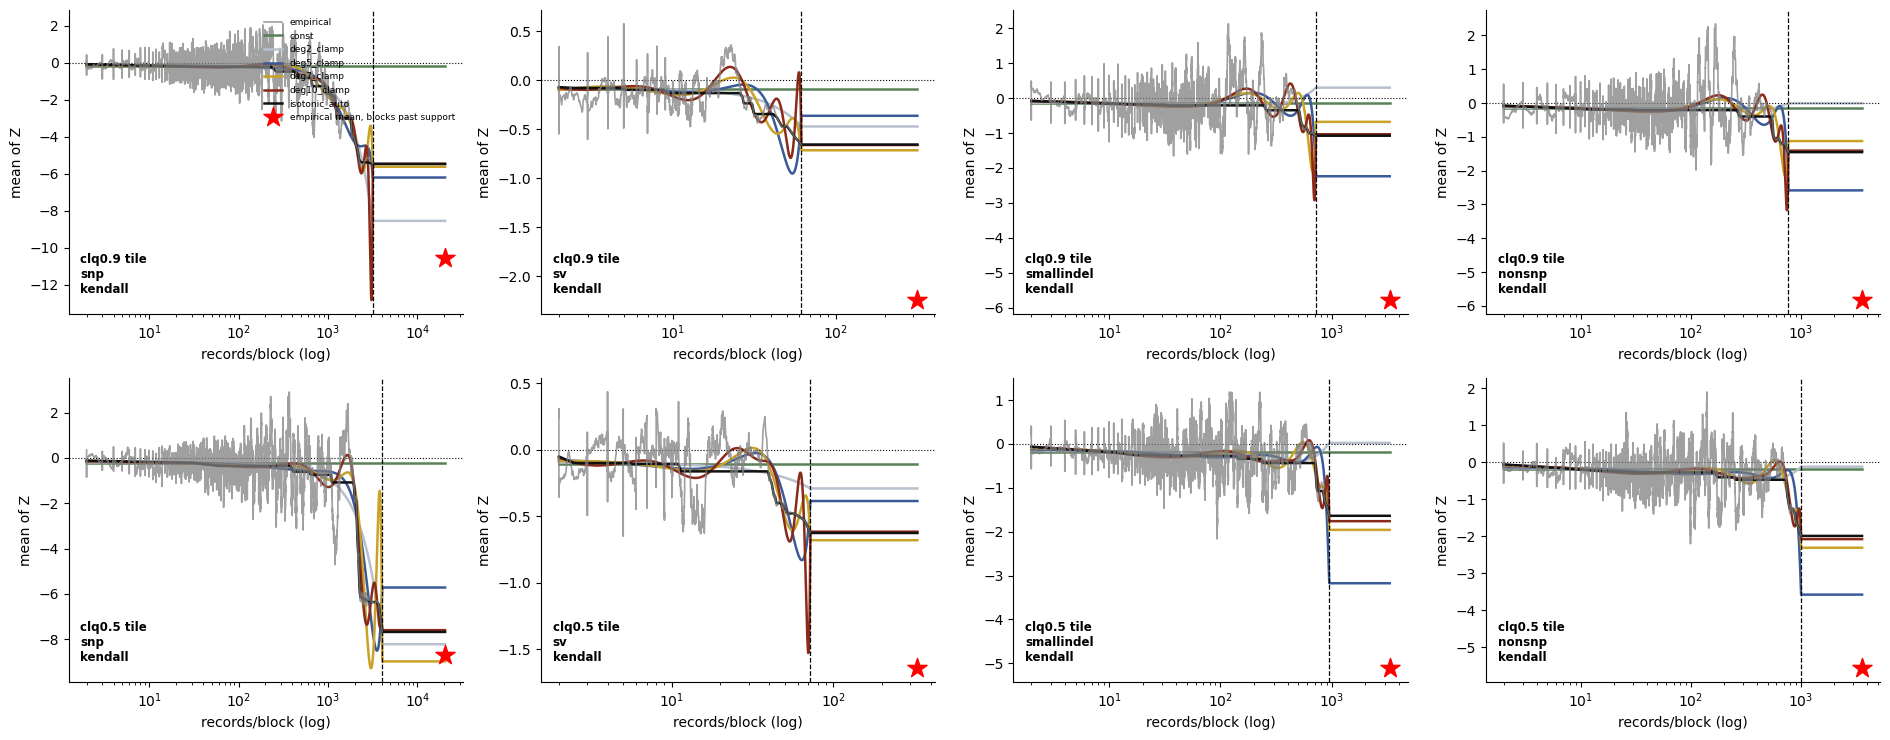

In [3]:

KM = ["const","deg2_clamp","deg5_clamp","deg7_clamp","deg10_clamp","isotonic_auto"]
for model in [MODEL]:
    fig, axes = plt.subplots(2, 4, figsize=(19, 7.5))
    for i, (lab, tag) in enumerate(DEFS.items()):
        for j, cls in enumerate(CLASSES):
            ax = axes[i][j]; g, X, sd, mn = get(tag, cls, model)
            ax.plot(X, mn, color="grey", lw=1.2, alpha=.75, zorder=4, label="empirical")
            grid = np.linspace(X.min(), g.SNPs.max(), 700)
            for k in KM:
                ax.plot(grid, fit(X, mn, grid, k), color=COL[k], lw=1.8, label=k)
            above = g[g.SNPs > X.max()]
            if len(above) >= 8:
                ax.scatter([g.SNPs.max()], [above.Z.mean()], marker="*", s=210, color="red",
                           zorder=8, label="empirical mean, blocks past support")
            ax.axvline(X.max(), ls="--", c="k", lw=.9); ax.axhline(0, ls=":", c="k", lw=.8)
            ax.set_xscale("log")
            ax.set_xlabel("records/block (log)"); ax.set_ylabel("mean of Z")
            ax.annotate(f"{lab}\n{cls}\n{model}", (0.03,0.06), xycoords="axes fraction",
                        fontsize=8.5, va="bottom", weight="bold")
            if i==0 and j==0: ax.legend(frameon=False, fontsize=6.5, loc="upper right")
            for sp in ["top","right"]: ax.spines[sp].set_visible(False)
    fig.tight_layout(); plt.show()


## 3. Zoom on the large-block region — where the decision actually lives

Upper 10% of the support range and beyond, linear x. The **red star** is the empirical
mean(Z) of the blocks that sit *past* the support edge — the value a fit ought to be heading
toward. Read off which curve gets closest to it, and note that only ~8–15 blocks per class
are out there, which is why no RMSE could adjudicate this.

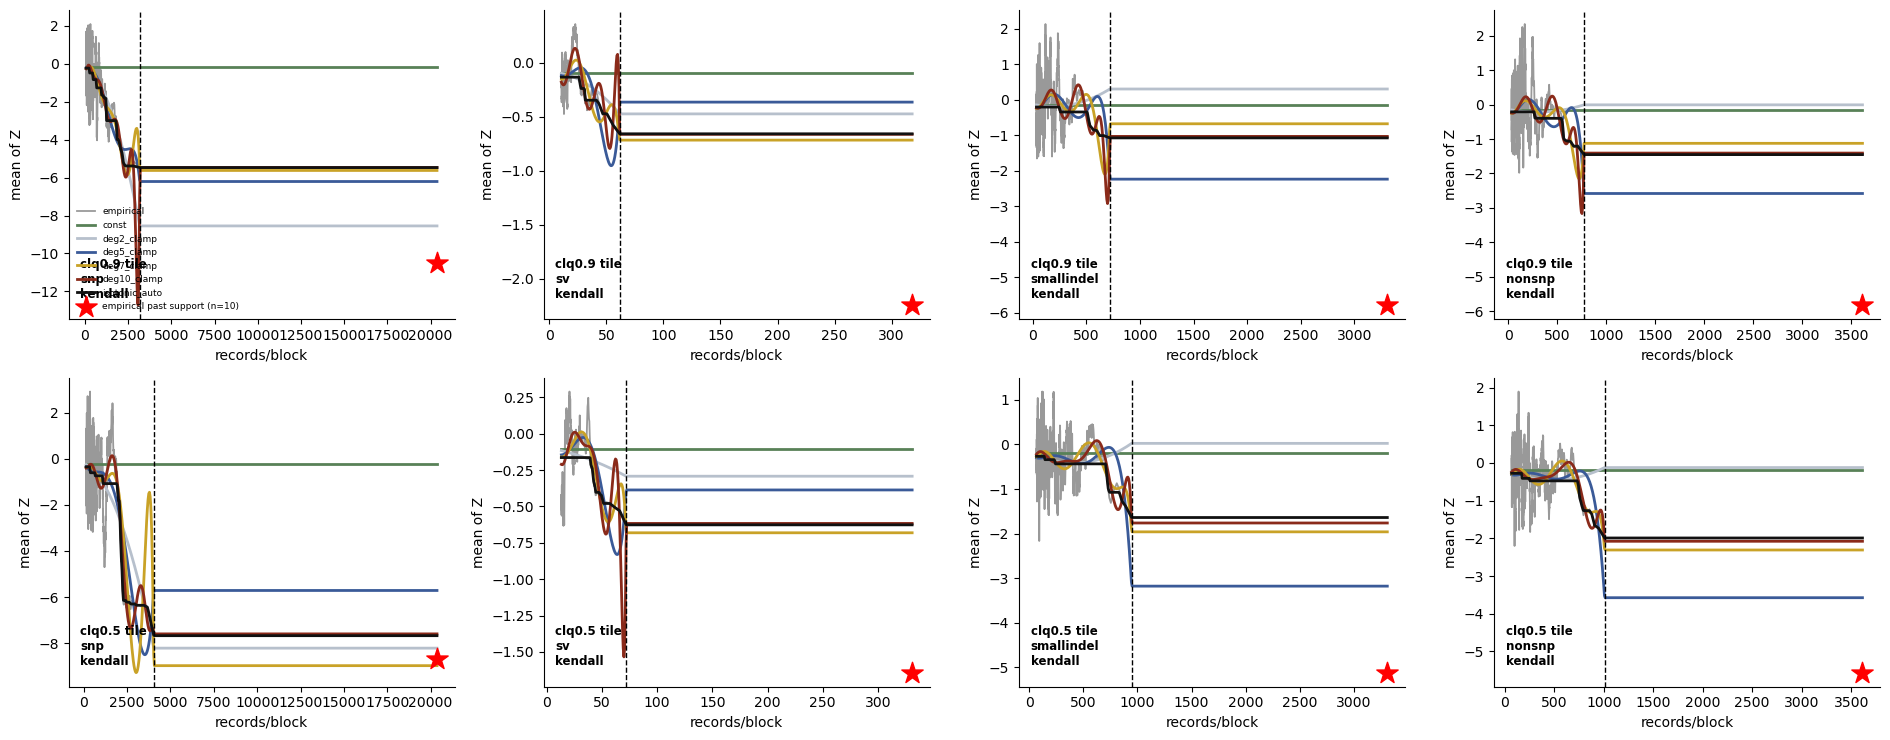

In [4]:

for model in [MODEL]:
    fig, axes = plt.subplots(2, 4, figsize=(19, 7.5))
    for i, (lab, tag) in enumerate(DEFS.items()):
        for j, cls in enumerate(CLASSES):
            ax = axes[i][j]; g, X, sd, mn = get(tag, cls, model)
            lo = np.quantile(X, 0.90); mx = g.SNPs.max()
            sel = X >= lo
            ax.plot(X[sel], mn[sel], color="grey", lw=1.3, alpha=.8, label="empirical")
            grid = np.linspace(lo, mx, 500)
            for k in KM:
                ax.plot(grid, fit(X, mn, grid, k), color=COL[k], lw=2.0, label=k)
            above = g[g.SNPs > X.max()]
            if len(above) >= 8:
                ax.scatter([mx], [above.Z.mean()], marker="*", s=260, color="red", zorder=8,
                           label=f"empirical past support (n={len(above)})")
            ax.axvline(X.max(), ls="--", c="k", lw=1.0)
            ax.set_xlabel("records/block"); ax.set_ylabel("mean of Z")
            ax.annotate(f"{lab}\n{cls}\n{model}", (0.03,0.06), xycoords="axes fraction",
                        fontsize=8.5, va="bottom", weight="bold")
            if i==0 and j==0: ax.legend(frameon=False, fontsize=6.5)
            for sp in ["top","right"]: ax.spines[sp].set_visible(False)
    fig.tight_layout(); plt.show()


## 4. Why "just use a higher degree" does not work

Booker's *"this will kind of overfit the data, but I think this is ok as the goal is simply
to interpolate"* is right in spirit, but only up to a point on this data. Even **clamped**,
deg-15 and deg-20 oscillate wildly (Runge phenomenon) near the sparse upper end of the fitted
range, where rolling points thin out. Large-block-band out-of-sample RMSE:

| fit | SD | mean |
|---|---|---|
| deg5_clamp | **1.174** | 1.063 |
| deg7_clamp | 1.257 | 1.096 |
| deg10_clamp | 1.301 | 1.185 |
| deg15_clamp | **11.44** | **9.78** |
| deg20_clamp | **216.5** | **149.1** |

Plotted below on the worst case. Also shown: the same fits *unclamped*, which is the −289
failure.

/tmp/ipykernel_2710113/2653603604.py:10: RankWarning: Polyfit may be poorly conditioned
  ax.plot(grid, fit(X, y, grid, k), color=COL[k], lw=1.6, label=k)
/tmp/ipykernel_2710113/2653603604.py:10: RankWarning: Polyfit may be poorly conditioned
  ax.plot(grid, fit(X, y, grid, k), color=COL[k], lw=1.6, label=k)


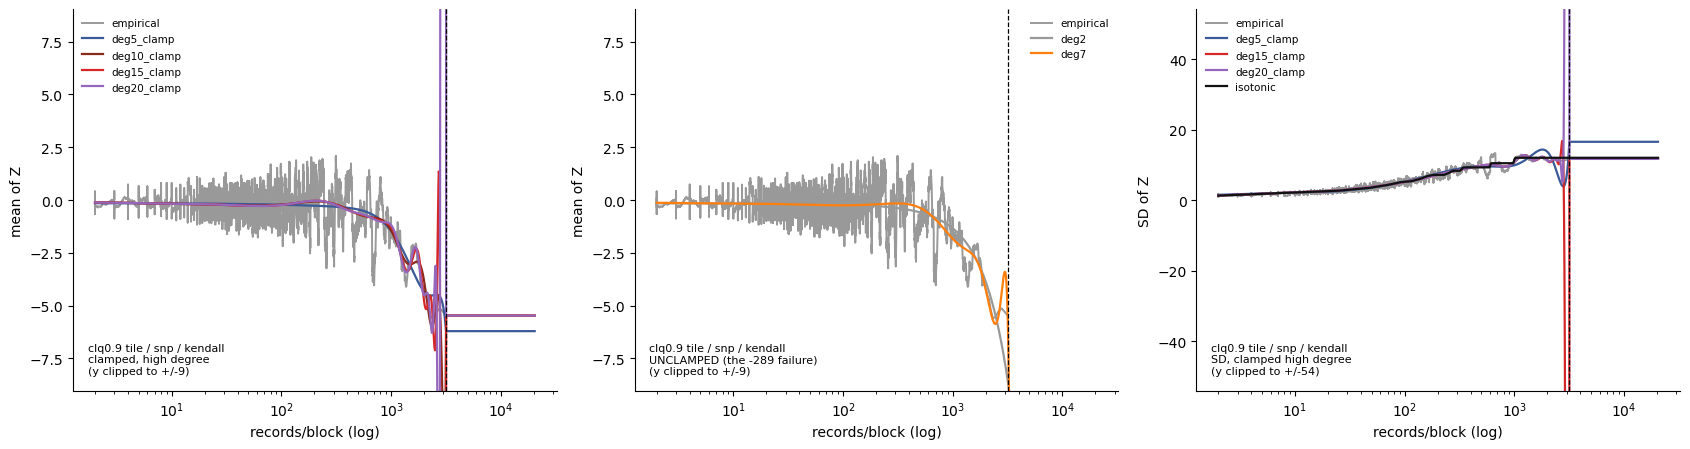

In [5]:

fig, axes = plt.subplots(1, 3, figsize=(17, 4.6))
g, X, sd, mn = get("clq09_tile", "snp", "kendall")
grid = np.linspace(X.min(), g.SNPs.max(), 900)
for ax, ks, ttl, y in [
        (axes[0], ["deg5_clamp","deg10_clamp","deg15_clamp","deg20_clamp"], "clamped, high degree", mn),
        (axes[1], ["deg2","deg7"], "UNCLAMPED (the -289 failure)", mn),
        (axes[2], ["deg5_clamp","deg15_clamp","deg20_clamp","isotonic"], "SD, clamped high degree", sd)]:
    ax.plot(X, y, color="grey", lw=1.4, alpha=.8, label="empirical")
    for k in ks:
        ax.plot(grid, fit(X, y, grid, k), color=COL[k], lw=1.6, label=k)
    ax.axvline(X.max(), ls="--", c="k", lw=.9)
    ax.set_xscale("log"); ax.set_xlabel("records/block (log)")
    ax.set_ylabel("mean of Z" if y is mn else "SD of Z")
    lim = np.percentile(np.abs(y), 99) * 6
    ax.set_ylim(-lim, lim)
    ax.annotate(f"clq0.9 tile / snp / kendall\n{ttl}\n(y clipped to +/-{lim:.0f})",
                (0.03,0.04), xycoords="axes fraction", fontsize=8, va="bottom")
    ax.legend(frameon=False, fontsize=7.5)
    for sp in ["top","right"]: ax.spines[sp].set_visible(False)
fig.tight_layout(); plt.show()


## 5. The numbers behind the zoom

Predicted mean(Z) at each class's largest block, against what those blocks empirically
average. This is the table the decision rests on — RMSE cannot see this region.

In [6]:

rows = []
for model in [MODEL]:
    for lab, tag in DEFS.items():
        for cls in CLASSES:
            g, X, sd, mn = get(tag, cls, model)
            mx = np.array([g.SNPs.max()], float)
            above = g[g.SNPs > X.max()]
            r = dict(model=model, blockdef=lab, cls=cls, support_to=round(float(X.max())),
                     maxN=int(mx[0]), n_past=len(above),
                     empirical=above.Z.mean() if len(above) >= 8 else np.nan)
            for k in ["const","deg2_clamp","deg5_clamp","deg7_clamp","isotonic_auto","deg2"]:
                r[k] = fit(X, mn, mx, k)[0]
            rows.append(r)
R = pd.DataFrame(rows)
print(R.round(2).to_string(index=False))
print("\nabsolute error vs the empirical past-support mean (lower better):")
E = R.dropna(subset=["empirical"]).copy()
for k in ["const","deg2_clamp","deg5_clamp","deg7_clamp","isotonic_auto"]:
    E["e_"+k] = (E[k] - E.empirical).abs()
print(E.groupby("model")[["e_const","e_deg2_clamp","e_deg5_clamp","e_deg7_clamp",
                          "e_isotonic_auto"]].mean().round(2).to_string())
print("\noverall mean |error|:")
print(E[[c for c in E.columns if c.startswith("e_")]].mean().sort_values().round(2).to_string())


  model    blockdef        cls  support_to  maxN  n_past  empirical  const  deg2_clamp  deg5_clamp  deg7_clamp  isotonic_auto    deg2
kendall clq0.9 tile        snp        3171 20365      10     -10.53  -0.18       -8.55       -6.21       -5.62          -5.47 -289.49
kendall clq0.9 tile         sv          62   318       8      -2.24  -0.09       -0.47       -0.36       -0.71          -0.66  -10.26
kendall clq0.9 tile smallindel         719  3309      14      -5.78  -0.14        0.30       -2.24       -0.68          -1.08   16.72
kendall clq0.9 tile     nonsnp         773  3613      14      -5.83  -0.14       -0.00       -2.58       -1.12          -1.45    9.95
kendall clq0.5 tile        snp        4044 20365      12      -8.67  -0.24       -8.22       -5.72       -8.98          -7.68 -179.76
kendall clq0.5 tile         sv          72   331      11      -1.64  -0.10       -0.29       -0.39       -0.68          -0.63   -2.62
kendall clq0.5 tile smallindel         947  3309      15      